In [1]:
import os
# os.chdir("../..")


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.io import loadmat
from scipy import interpolate
from scipy.signal import savgol_filter
import seaborn as sns
from matplotlib.lines import Line2D
from scipy import optimize
from matplotlib import cm
from scipy import signal
from scipy.io import loadmat
import matplotlib.backends.backend_pdf
from scipy.interpolate import RegularGridInterpolator

import matplotlib as mpl
from matplotlib import colors
import netCDF4 as nc



from pathlib import Path
root = str(Path.cwd().parent.parent)
import sys
sys.path.append(f'{root}/src')
import util
from glsim import *

In [3]:
#### reading in transects
jdf = pd.read_excel(f'{root}/inputs/flowlines/jdf_update.xlsx')
sv = pd.read_excel(f'{root}/inputs/flowlines/sv.xlsx')
ysv = pd.read_excel(f'{root}/inputs/flowlines/ysv_update.xlsx')

In [4]:
love_num_names = util.get_files(f'{root}/inputs/earthmodels/matfiles/','.mat')

In [5]:
love_num_names

['prem.l50.ump2.lm3.yt.mat',
 'prem.l50.ump2.lm3_lvz_200km.mx.mat',
 'prem.l50.ump2.lm3_lvz_70km.yt.mat',
 'prem.l90.ump2.lm3_lvz_200km.mx.mat',
 'prem.l50.ump5.lm3_lvz_200km.yt.mat',
 'prem.l50.ump5.lm3_lvz_200km.mx.mat',
 'prem.l50.ump2.lm3.mx.mat',
 'prem.l90.ump2.lm3_lvz_200km.yt.mat',
 'prem.l50.ump2.lm3_lvz_70km.mx.mat',
 'prem.l50.ump2.lm3_lvz_200km.yt.mat']

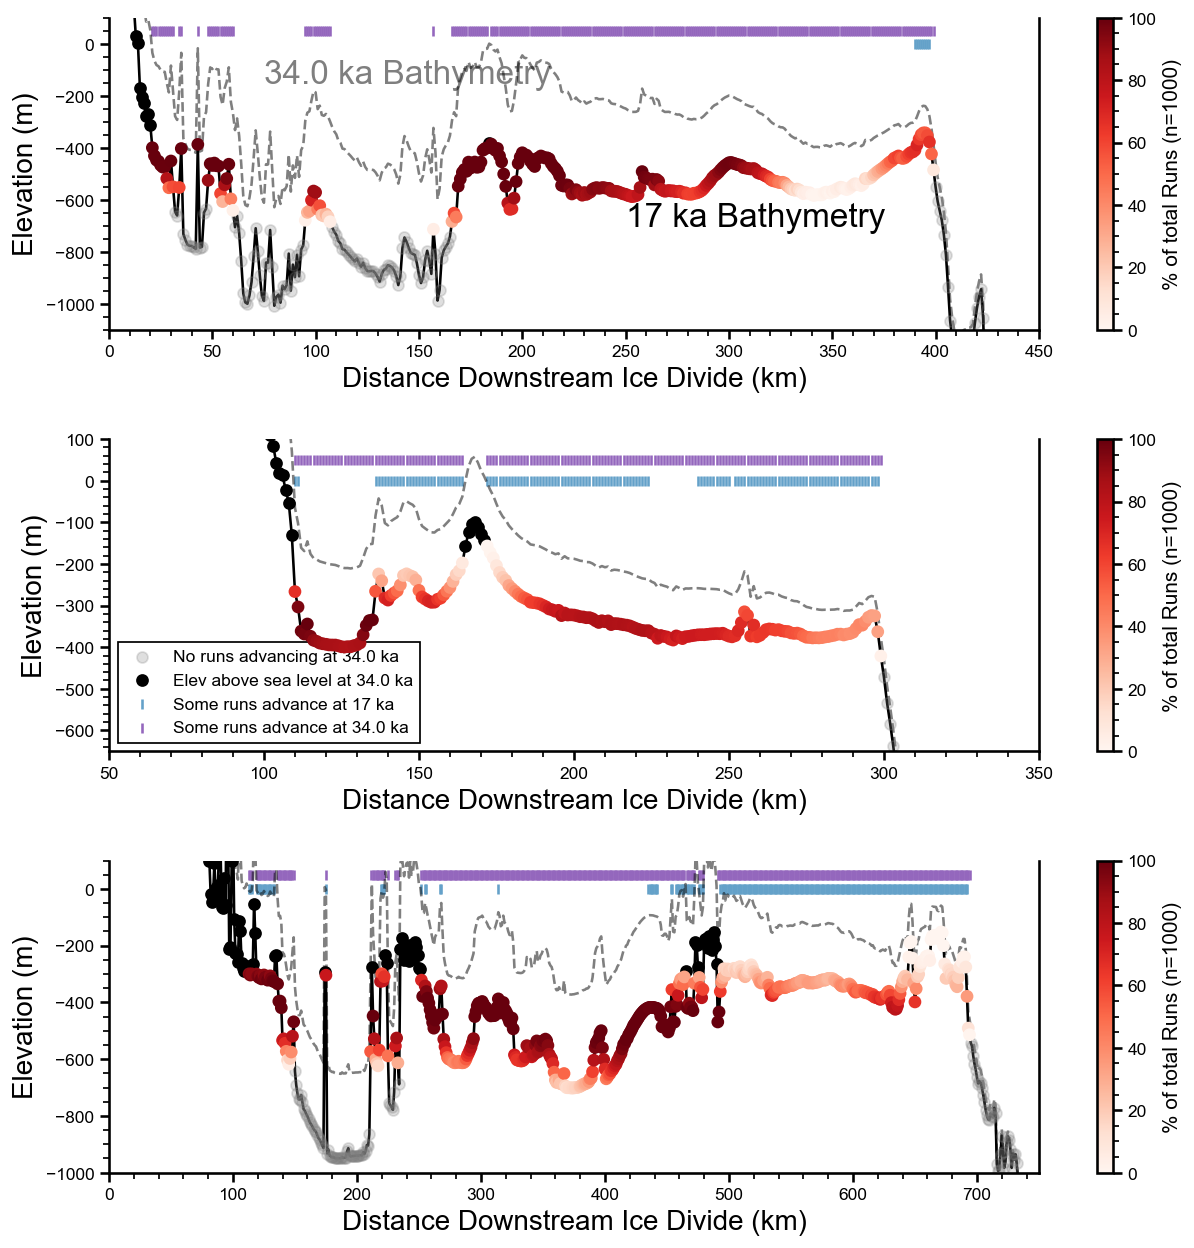

In [27]:
### create fnames for rsl
flow = [sv, ysv, jdf]
titles = ['Skeena_Valley', 'Yakutat_Sea_Valley', 'Juan_de_Fuca']
ice_hist = ['CISLGM_icepc_022226_highres_512']
# ice_hist = ['daltonMarg_ice7g_gowanEarth_iter02_patched_highres_512']

# for now only care about transient lvz
earth_models = ['prem.l50.ump2.lm3_lvz_200km.yt.mat']
# for em in love_num_names:
#     earth_models = [em]
    
ymins = [-1100, -650, -1000]
ymaxs = [100, 100, 100]
xmins = [0,50,0]
xmaxs = [450,350,750]


sub_times = [34., 17]
alphas = [0.5, 1]
ls = ['dashed', 'solid']
s = 40
bf = 16

fig,ax= plt.subplots(3,1,figsize=(12,12))
for num,fl in enumerate(flow):
    for ice in ice_hist:
        for lm in earth_models:
            fname = f'rsl-{ice}-{lm}.nc'
            rsl = nc.Dataset(f'{root}/inputs/rsl/{fname}')
            df, pp, fl_outs = calc_ppoints(rsl, fl, sub_times, lm, FLouts = True)
            ### calc N, total number of runs
            N = fl_outs['elevfluxes'].shape[1] * fl_outs['elevfluxes'].shape[2] * fl_outs['elevfluxes'].shape[3] * fl_outs['elevfluxes'].shape[4]

            ### find number of positive gl fluxes at each time
            gl_fluxes = {}
            for t in sub_times:
                gl_fluxes[str(t)] = np.zeros(fl['distance'].shape[0])
                for i in np.arange(len(gl_fluxes[str(t)])):
                    gl_fluxes[str(t)][i] = np.sum(fl_outs[f'{str(t)}ka{lm}fluxes'][i,:,:,:,:] >=0)

            ### create interpolation for flowline
            f = interpolate.interp1d(fl['distance']/1e3, fl[f"{str(sub_times[-1])}ka{lm}"])
            ### plot both bathymetries
            for n,t in enumerate(sub_times):
                ax[num].plot(fl['distance']/1e3, fl[f"{str(t)}ka{lm}"],color = 'k',alpha = alphas[n],linestyle = ls[n])

            ### plot change of points
            del_gl_flux = gl_fluxes[str(sub_times[0])]/N*1e2 - gl_fluxes[str(sub_times[-1])]/N*1e2
            del_gl_flux[gl_fluxes[str(sub_times[0])] == 0] = np.nan
            
            ### find locations where still advancing
            pos_gl_flux_end = gl_fluxes[str(sub_times[-1])]
            pos_gl_flux_start = gl_fluxes[str(sub_times[0])]
            
            pos_gl_flux_end[pos_gl_flux_end == 0] = np.nan
            ### removing locations where start time is above sea level
            pos_gl_flux_end[fl[f"{str(sub_times[0])}ka{lm}"] >= 0] = np.nan
            pos_gl_flux_start[pos_gl_flux_start == 0] = np.nan
            ### remove locations where above sea level
            for t in sub_times:
                del_gl_flux[fl[f"{str(t)}ka{lm}"] >= 0] = -999

            ### plotting retreating
            img = ax[num].scatter(fl['distance'][del_gl_flux!=-999]/1e3, f(fl['distance'][del_gl_flux!=-999]/1e3),zorder=10,s=s, c = del_gl_flux[del_gl_flux!=-999],cmap = 'Reds', vmin = 0, vmax = 100)
            ax[num].scatter(fl['distance'][np.isnan(del_gl_flux)]/1e3, f(fl['distance'][np.isnan(del_gl_flux)]/1e3),zorder=2,s=s, color = 'grey',alpha = 0.25,label = f'No runs advancing at {sub_times[0]} ka')
            ax[num].scatter(fl['distance'][del_gl_flux == -999]/1e3, f(fl['distance'][del_gl_flux == -999]/1e3),zorder=2,s=s, color = 'black',alpha = 1,label = f'Elev above sea level at {sub_times[0]} ka')
            ### plotting still advancing
            sub_end = np.logical_and(~np.isnan(pos_gl_flux_end),fl[f"{str(sub_times[-1])}ka{lm}"] < 0 )
            sub_start = np.logical_and(~np.isnan(pos_gl_flux_start),fl[f"{str(sub_times[0])}ka{lm}"] < 0 )
            if np.sum(sub_end) != 0:
                ax[num].scatter(fl['distance'][sub_end]/1e3, (np.zeros(len(fl['distance'][sub_end]))), alpha = 1,label = f'Some runs advance at {sub_times[-1]} ka',zorder=1,s=s,marker='|')
            if np.sum(sub_start) !=0:
                ax[num].scatter(fl['distance'][sub_start]/1e3, (np.ones(len(fl['distance'][sub_start]))*50), alpha = 1,label = f'Some runs advance at {sub_times[0]} ka',zorder=1,color='tab:purple',s=s,marker='|')
            
                        
            cbar = plt.colorbar(img, ax=ax[num])
            cbar.set_label(f'% of total Runs (n={N})')
            # ax[num].set_title(titles[num],fontsize=12, weight='bold')
            ax[num].set_xlabel('Distance Downstream Ice Divide (km)',fontsize=bf)
            ax[num].set_ylabel('Elevation (m)',fontsize=bf)
            ax[num].set_ylim(ymins[num], ymaxs[num])
            ax[num].set_xlim(xmins[num], xmaxs[num])
            ax[num].spines['top'].set_visible(False)
            if num == 1:
                ax[num].legend(fontsize=10,loc='lower left')
            
ax[0].text(75,-150, f'{sub_times[0]} ka Bathymetry ' ,fontsize=bf*1.2,color='k',alpha = 0.5)
ax[0].text(250,-700, f'{sub_times[-1]} ka Bathymetry',fontsize=bf*1.2,color='k')
# plt.suptitle(f'Runs that Advanced at {sub_times[0]} ka but Retreated at {sub_times[-1]} ka {ice_hist[0]}',weight = 'bold')
# plt.suptitle(f'Runs that Advanced at {sub_times[0]} ka but Retreated at {sub_times[-1]} ka',weight = 'bold')
plt.subplots_adjust(hspace=0.35)
plt.savefig(f'{root}/figures/f03_delGLFlux.pdf')

In [ ]:
### create fnames for rsl
flow = [sv, ysv, jdf]
titles = ['Skeena_Valley', 'Yakutat_Sea_Valley', 'Juan_de_Fuca']
ice_hist = ['CISLGM_icepc_022226_highres_512']
# earth_models = ['prem.l50.ump2.lm3_lvz_200km.yt', 'prem.l50.ump2.lm3_lvz_200km.mx', 'prem.l48C.ump2.lm3.mx']
# for now only care about transient lvz
earth_models = ['prem.l50.ump2.lm3_lvz_200km.yt.mat']

ymins = [-1100, -600, -1000]
ymaxs = [0, 0, 0]
xmins = [0,50,0]
xmaxs = [450,350,750]


# sub_times = [26., 26 - .075]
sub_times = [18., 18 - .075]
alphas = [0.5, 1]
ls = ['dashed', 'solid']
s = 40
bf = 10

fig,ax= plt.subplots(3,1,figsize=(12,12))
for num,fl in enumerate(flow):
    for ice in ice_hist:
        for lm in earth_models:
            fname = f'rsl-{ice}-{lm}.nc'
            rsl = nc.Dataset(f'inputs/rsl/{fname}')
            df, pp, fl_outs = calc_ppoints(rsl, fl, sub_times, lm, FLouts = True)
            ### calc N, total number of runs
            N = fl_outs['elevfluxes'].shape[1] * fl_outs['elevfluxes'].shape[2] * fl_outs['elevfluxes'].shape[3] * fl_outs['elevfluxes'].shape[4]

            ### find number of positive gl fluxes at each time
            gl_fluxes = {}
            for t in sub_times:
                gl_fluxes[str(t)] = np.zeros(fl['distance'].shape[0])
                for i in np.arange(len(gl_fluxes[str(t)])):
                    gl_fluxes[str(t)][i] = np.sum(fl_outs[f'{str(t)}ka{lm}fluxes'][i,:,:,:] >=0)

            ### create interpolation for flowline
            f = interpolate.interp1d(fl['distance']/1e3, fl[f"{str(sub_times[-1])}ka{lm}"])
            ### plot both bathymetries
            for n,t in enumerate(sub_times):
                ax[num].plot(fl['distance']/1e3, fl[f"{str(t)}ka{lm}"],color = 'k',alpha = alphas[n],linestyle = ls[n])

            ### plot change of points
            del_gl_flux = gl_fluxes[str(sub_times[0])]/N*1e2 - gl_fluxes[str(sub_times[-1])]/N*1e2
            del_gl_flux[gl_fluxes[str(sub_times[0])] == 0] = np.nan
            
            ### find locations where still advancing
            pos_gl_flux_end = gl_fluxes[str(sub_times[-1])]
            pos_gl_flux_start = gl_fluxes[str(sub_times[0])]
            
            pos_gl_flux_end[pos_gl_flux_end == 0] = np.nan
            ### removing locations where start time is above sea level
            pos_gl_flux_end[fl[f"{str(sub_times[0])}ka{lm}"] >= 0] = np.nan
            pos_gl_flux_start[pos_gl_flux_start == 0] = np.nan
            ### remove locations where above sea level
            for t in sub_times:
                del_gl_flux[fl[f"{str(t)}ka{lm}"] >= 0] = -999

            ### plotting retreating
            img = ax[num].scatter(fl['distance'][del_gl_flux!=-999]/1e3, f(fl['distance'][del_gl_flux!=-999]/1e3),zorder=10,s=s, c = del_gl_flux[del_gl_flux!=-999],cmap = 'Reds', vmin = 0, vmax = 100)
            ax[num].scatter(fl['distance'][np.isnan(del_gl_flux)]/1e3, f(fl['distance'][np.isnan(del_gl_flux)]/1e3),zorder=2,s=s, color = 'grey',alpha = 0.25,label = f'No runs advancing at {sub_times[0]} ka')
            ax[num].scatter(fl['distance'][del_gl_flux == -999]/1e3, f(fl['distance'][del_gl_flux == -999]/1e3),zorder=2,s=s, color = 'black',alpha = 1,label = f'Elev above sea level at {sub_times[0]} ka')
            ### plotting still advancing
            sub_end = np.logical_and(~np.isnan(pos_gl_flux_end),fl[f"{str(sub_times[-1])}ka{lm}"] < 0 )
            sub_start = np.logical_and(~np.isnan(pos_gl_flux_start),fl[f"{str(sub_times[0])}ka{lm}"] < 0 )
            if np.sum(sub_end) != 0:
                ax[num].bar(fl['distance'][sub_end]/1e3, (np.ones(len(fl['distance'][sub_end]))*-1200), width = 1, alpha = 0.2,label = f'Some runs advance at {sub_times[-1]} ka',zorder=1)
            if np.sum(sub_start) !=0:
                ax[num].bar(fl['distance'][sub_start]/1e3, (np.ones(len(fl['distance'][sub_start]))*-1200), width = 1, alpha = 0.2,label = f'Some runs advance at {sub_times[0]} ka',zorder=1,color='tab:purple')
            
                        
            cbar = plt.colorbar(img, ax=ax[num])
            cbar.set_label(f'% of total Runs (n={N})')
            ax[num].set_title(titles[num],fontsize=12, weight='bold')
            ax[num].set_xlabel('Distance Downstream Ice Divide (km)',fontsize=bf)
            ax[num].set_ylabel('Elevation (m)',fontsize=bf)
            ax[num].set_ylim(ymins[num], ymaxs[num])
            ax[num].set_xlim(xmins[num], xmaxs[num])
            if num == 2:
                loc = 'lower right'
            else:
                loc = 'upper right'
            ax[num].legend(fontsize=10,loc='best')
ax[0].text(75,-150, f'{sub_times[0]} ka Bathymetry ' ,fontsize=bf*1.2,color='k',alpha = 0.5)
ax[0].text(250,-700, f'{sub_times[-1]} ka Bathymetry',fontsize=bf*1.2,color='k')
plt.suptitle(f'Runs that Advanced at {sub_times[0]} ka but Retreated at {sub_times[-1]} ka',weight = 'bold')
plt.tight_layout()
# plt.savefig('figures/sf_delGLFlux_75yrs_jdf.pdf')

In [ ]:
# ### create fnames for rsl
# flow = [sv, ysv, jdf]
# titles = ['Skeena_Valley', 'Yakutat_Sea_Valley', 'Juan_de_Fuca']
# ice_hist = ['CISLGM_icepc_022226_highres']
# # earth_models = ['prem.l50.ump2.lm3_lvz_200km.yt', 'prem.l50.ump2.lm3_lvz_200km.mx', 'prem.l48C.ump2.lm3.mx']
# # for now only care about transient lvz
# earth_models = ['prem.l50.ump2.lm3_lvz_200km.yt']

# ymins = [-1100, -600, -1000]
# ymaxs = [0, 0, 0]
# xmins = [0,50,0]
# xmaxs = [450,350,750]


# sub_times = [34.]
# alphas = [0.5, 1]
# smbs = [0,-1]
# ls = ['dashed', 'solid']
# s = 40
# bf = 10

# fig,ax= plt.subplots(3,1,figsize=(12,12))
# for num,fl in enumerate(flow):
#     for ice in ice_hist:
#         for lm in earth_models:
#             fname = f'rsl-{ice}-{lm}.nc'
#             rsl = nc.Dataset(f'inputs/rsl/{fname}')
#             df, pp, fl_outs = calc_ppoints(rsl, fl, sub_times, lm, FLouts = True)
#             ### calc N, total number of runs
#             N = fl_outs['elevfluxes'].shape[1] * fl_outs['elevfluxes'].shape[2] * fl_outs['elevfluxes'].shape[4]

#             ### find number of positive gl fluxes at smb extreme for 34 ka topography
#             gl_fluxes = {}
#             for sm in smbs:
#                 gl_fluxes[str(sm)] = np.zeros(fl['distance'].shape[0])
#                 for i in np.arange(len(gl_fluxes[str(sm)])):
#                     gl_fluxes[str(sm)][i] = np.sum(fl_outs[f'{str(sub_times[0])}ka{lm}fluxes'][i,:,:,sm,:] >=0)

#             ### create interpolation for flowline
#             f = interpolate.interp1d(fl['distance']/1e3, fl[f"{str(sub_times[-1])}ka{lm}"])
#             ### plot both bathymetries
#             for n,t in enumerate(sub_times):
#                 ax[num].plot(fl['distance']/1e3, fl[f"{str(sub_times[0])}ka{lm}"],color = 'k',alpha = 1,linestyle = 'solid')

#             ### plot change of points
#             del_gl_flux = gl_fluxes[str(smbs[-1])]/N*1e2 - gl_fluxes[str(smbs[0])]/N*1e2
#             del_gl_flux[gl_fluxes[str(smbs[-1])] == 0] = np.nan
#             ### find locations where still advancing
#             pos_gl_flux_end = gl_fluxes[str(smbs[0])]
#             pos_gl_flux_start = gl_fluxes[str(smbs[-1])]
            
#             pos_gl_flux_end[pos_gl_flux_end == 0] = np.nan
#             ### removing locations where start time is above sea level
#             pos_gl_flux_end[fl[f"{str(sub_times[0])}ka{lm}"] >= 0] = np.nan
#             pos_gl_flux_start[pos_gl_flux_start == 0] = np.nan
#             ### remove locations where above sea level
#             for t in sub_times:
#                 del_gl_flux[fl[f"{str(sub_times[0])}ka{lm}"] >= 0] = -999

#             ### plotting retreating
#             img = ax[num].scatter(fl['distance'][del_gl_flux!=-999]/1e3, f(fl['distance'][del_gl_flux!=-999]/1e3),zorder=10,s=s, c = del_gl_flux[del_gl_flux!=-999],cmap = 'Reds', vmin = 0, vmax = 100)
#             ax[num].scatter(fl['distance'][np.isnan(del_gl_flux)]/1e3, f(fl['distance'][np.isnan(del_gl_flux)]/1e3),zorder=2,s=s, color = 'grey',alpha = 0.25,label = f'No runs advancing with smb = 1.25 m/yr')
#             ax[num].scatter(fl['distance'][del_gl_flux == -999]/1e3, f(fl['distance'][del_gl_flux == -999]/1e3),zorder=2,s=s, color = 'black',alpha = 1,label = f'Elev above sea level at {34} ka')
#             ### plotting still advancing
#             sub_end = np.logical_and(~np.isnan(pos_gl_flux_end),fl[f"{str(sub_times[-1])}ka{lm}"] < 0 )
#             sub_start = np.logical_and(~np.isnan(pos_gl_flux_start),fl[f"{str(sub_times[0])}ka{lm}"] < 0 )
#             if np.sum(sub_end) != 0:
#                 ax[num].bar(fl['distance'][sub_end]/1e3, (np.ones(len(fl['distance'][sub_end]))*-1200), width = 1, alpha = 0.2,label = f'Some runs advance with smb = 0.1 m/yr',zorder=1)
#             if np.sum(sub_start) !=0:
#                 ax[num].bar(fl['distance'][sub_start]/1e3, (np.ones(len(fl['distance'][sub_start]))*-1200), width = 1, alpha = 0.2,label = f'Some runs advance with smb = 1.25 m/yr',zorder=1,color='tab:purple')
            
                        
#             cbar = plt.colorbar(img, ax=ax[num])
#             cbar.set_label(f'% of total Runs (n={N})')
#             ax[num].set_title(titles[num],fontsize=12, weight='bold')
#             ax[num].set_xlabel('Distance Downstream Ice Divide (km)',fontsize=bf)
#             ax[num].set_ylabel('Elevation (m)',fontsize=bf)
#             ax[num].set_ylim(ymins[num], ymaxs[num])
#             ax[num].set_xlim(xmins[num], xmaxs[num])
#             if num == 2:
#                 loc = 'lower right'
#             else:
#                 loc = 'upper right'
#             ax[num].legend(fontsize=10,loc='best')
# ax[0].text(75,-150, f'{sub_times[0]} ka Bathymetry ' ,fontsize=bf*1.2,color='k',alpha = 0.5)
# # ax[0].text(250,-700, f'{sub_times[-1]} ka Bathymetry',fontsize=bf*1.2,color='k')
# plt.suptitle(f'Runs that Advanced with smb = 1.25 m/yr ka but Retreated awith smb = 0.1 m/yr',weight = 'bold')
# plt.tight_layout()
# plt.savefig('figures/sf_delGLFlux_delSMB.pdf')